### Programming for Biomedical Informatics
#### Week 10 - Building & Analysing a Patient Similarity Network using Multi-modal Data Fusion

In this notebook we are going to use similarity network fusion (SNF) to integrate gene expression and DNA methylation data from individuals in the TCGA LUAD dataset that we used previously. This is a dataset for lung cancer and our meta-data includes information about smoking status, cancer status, gender, and ethnicity.

Our approach will first be to use Lasso regression against the smoking level (cigarettes_per_day) for an individual to identify features that are informative - this is one of many possible ways to reduce the number of features in our analysis.

Once we have reduced the number of features for both modalities we will build independent patient similarity networks (PSNs) from them.

Next we will use SNF to fuse the networks and maximise patient retention in the data (different numbers of patients have data for each modality)

Once fused we will sparsify the network to retain only the strongest edges and then perform clustering to see what sub-groups we find and how they relate to cancer status

The notebook is designed to give you an idea of how you might approach such an integrative approach we've made some assumptions and simplifying decisions along the way to make this tractable for the time we have in a session.

The data files you need for this notebook can be downloaded [here](https://datasync.ed.ac.uk/index.php/s/epDk1uiyWnz9UNF) with password 'pbi2025', put this data in a folder called 'data' that's located in the same folder as the notebook.

In [29]:
# import libraries
import pickle as pk
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
import snf
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import the DNA Methylation Data
with open("data/ISMB_TCGA_DNAm.pkl", "rb") as f:
    dnaMet = pk.load(f)

# Extract the Methylation Data
metData = dnaMet['datExpr']
metPatients, metFeatures = metData.shape
print(f'We have methylation data for',metPatients,'patients with',metFeatures,'features')

# Extract the MetaData
metMeta = dnaMet['datMeta']
metMeta.head()

We have methylation data for 459 patients with 300000 features


,patient,race,gender,sample_type,cigarettes_per_day,Smoked
rownames,,,,,,
TCGA-55-7914,TCGA-55-7914,white,female,Primary Tumor,0.273973,Smoker
TCGA-38-4631,TCGA-38-4631,white,female,Primary Tumor,2.191781,Smoker
TCGA-73-4658,TCGA-73-4658,white,female,Primary Tumor,1.369863,Smoker
TCGA-50-5932,TCGA-50-5932,white,male,Primary Tumor,0.000000,Never
TCGA-55-7576,TCGA-55-7576,black or african american,male,Primary Tumor,0.000000,Never


In [3]:
# Import the Gene Expression Data
with open("data/ISMB_TCGA_GE.pkl", "rb") as f:
    dnaExp = pk.load(f)

# Extract the Gene Expression Data
expData = dnaExp['datExpr']
expPatients, expFeatures = expData.shape
print(f'We have gene expression data for',expPatients,'patients with',expFeatures,'features')

# Extract the MetaData
expMeta = dnaExp['datMeta']
expMeta.head()

We have gene expression data for 498 patients with 22637 features


,patient,race,gender,sample_type,cigarettes_per_day,Smoked,sizeFactor,replaceable
_row,,,,,,,,
TCGA-38-7271,TCGA-38-7271,white,female,Primary Tumor,1.3699,Smoker,0.5841,True
TCGA-55-7914,TCGA-55-7914,white,female,Primary Tumor,0.274,Smoker,0.9873,True
TCGA-95-7043,TCGA-95-7043,white,female,Primary Tumor,2.1918,Smoker,0.5439,True
TCGA-73-4658,TCGA-73-4658,white,female,Primary Tumor,1.3699,Smoker,0.7715,True
TCGA-86-8076,TCGA-86-8076,white,male,Primary Tumor,0,Never,1.313,True


In [4]:
# # Feature Selection using Lasso Regression

# # regress the DNAMet features against the cigarettes per day
# # Basic penalized regression: DNAm features -> cigarettes_per_day

# # Response variable
# y = metMeta['cigarettes_per_day']

# # Drop samples with missing response
# valid_idx = y.dropna().index
# y = y.loc[valid_idx]

# # Align methylation matrix rows to valid samples
# X = metData.loc[valid_idx]

# # Optional: remove features with too low variance (speeds up)
# var_filter = VarianceThreshold(threshold=0.0005)  # adjust threshold as needed

# # Build pipeline: variance filter -> scaling -> LassoCV
# pipe = Pipeline([
#     ('var', var_filter),
#     ('scale', StandardScaler(with_mean=False)),  # with_mean=False for sparse-like large matrices
#     ('lasso', LassoCV(cv=5, n_jobs=-1, max_iter=5000, verbose=False))
# ])

# # Fit model
# pipe.fit(X, y)

# lasso = pipe.named_steps['lasso']
# filtered_feature_names = X.columns[var_filter.get_support()]

# # Extract non-zero coefficients
# coef = lasso.coef_
# nonzero_mask = coef != 0
# selected_features = filtered_feature_names[nonzero_mask]
# selected_coefs = coef[nonzero_mask]

# # Report
# print(f"Total original features: {X.shape[1]}")
# print(f"Features after variance filter: {len(filtered_feature_names)}")
# print(f"Non-zero (selected) features: {len(selected_features)}")

# # Build results DataFrame
# results = pd.DataFrame({
#     'feature': selected_features,
#     'coefficient': selected_coefs
# }).sort_values('coefficient', key=np.abs, ascending=False)

# results.head(20)

In [5]:
# # Store the selected feature IDs and their coefficients

# # Save feature IDs and coefficients to CSV
# results.to_csv('data/selected_DNAm_features.csv', index=False)

# print(f"Saved {len(selected_features)} selected features to:")
# print("  - data/selected_DNAm_features.csv (with coefficients)")

In [6]:
# # Feature Selection using Lasso Regression

# # regress the gene expression features against the cigarettes per day
# # Basic penalized regression: gene expression features -> cigarettes_per_day

# # Response variable
# y = expMeta['cigarettes_per_day']

# # Drop samples with missing response
# valid_idx = y.dropna().index
# y = y.loc[valid_idx]

# # Align gene expression matrix rows to valid samples
# X = expData.loc[valid_idx]

# # Optional: remove features with too low variance (speeds up)
# var_filter = VarianceThreshold(threshold=0.01)  # adjust threshold as needed

# # Build pipeline: variance filter -> scaling -> LassoCV
# pipe = Pipeline([
#     ('var', var_filter),
#     ('scale', StandardScaler()),
#     ('lasso', LassoCV(cv=5, n_jobs=-1, max_iter=5000, verbose=False))
# ])

# # Fit model
# pipe.fit(X, y)

# lasso_ge = pipe.named_steps['lasso']
# filtered_feature_names_ge = X.columns[var_filter.get_support()]

# # Extract non-zero coefficients
# coef_ge = lasso_ge.coef_
# nonzero_mask_ge = coef_ge != 0
# selected_features_ge = filtered_feature_names_ge[nonzero_mask_ge]
# selected_coefs_ge = coef_ge[nonzero_mask_ge]

# # Report
# print(f"Total original features: {X.shape[1]}")
# print(f"Features after variance filter: {len(filtered_feature_names_ge)}")
# print(f"Non-zero (selected) features: {len(selected_features_ge)}")

# # Build results DataFrame
# results_ge = pd.DataFrame({
#     'feature': selected_features_ge,
#     'coefficient': selected_coefs_ge
# }).sort_values('coefficient', key=np.abs, ascending=False)

# # Display results
# print(f"\nTop 20 selected genes:")
# results_ge.head(20)

In [7]:
# # Store the selected feature IDs and their coefficients

# # Save feature IDs and coefficients to CSV
# results_ge.to_csv('data/selected_GE_features.csv', index=False)

# print(f"Saved {len(selected_features_ge)} selected features to:")
# print("  - data/selected_DNAm_features.csv (with coefficients)")

In [8]:
import pandas as pd
# subset the main data by these features to create the reduced size matrices from which we will build the PSNs

# load the selected features and subset the data
metFeatures = pd.read_csv('./data/selected_DNAm_features.csv')
geFeatures = pd.read_csv('./data/selected_GE_features.csv')

# subset metData by selected features
metData = metData[metFeatures['feature']]
metPatients,metFeatures = metData.shape
print(f'There are',metPatients,'patients with',metFeatures,'methylation sites selected')

# select expData by selected features
expData = expData[geFeatures['feature']]
expPatients,expFeatures = expData.shape
print(f'There are',expPatients,'patients with',expFeatures,'genes selected')

There are 459 patients with 234 methylation sites selected
There are 498 patients with 86 genes selected


In [9]:
# It's usually a good idea to us a dimensionality reduction method to look for outliers and distributions of samples
# Here we will do a basic PCA

# expression data

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# scale features, run PCA on 2-dimensions
X = expData.values
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)
sample_pca = pd.DataFrame(pcs, columns=['PC1', 'PC2'], index=expData.index)

# add the sample_type so we can see if cancerous and non-cancerous samples are split
sample_pca = sample_pca.join(expMeta['sample_type'])
sample_pca.index.name = 'sample_id'
print(sample_pca)

                   PC1       PC2    sample_type
sample_id                                      
TCGA-38-7271 -4.311730  1.447648  Primary Tumor
TCGA-55-7914 -0.183837 -3.953148  Primary Tumor
TCGA-95-7043  4.402626  0.816755  Primary Tumor
TCGA-73-4658 -2.393388 -1.877763  Primary Tumor
TCGA-86-8076 -0.875126 -0.085040  Primary Tumor
...                ...       ...            ...
TCGA-86-8073  1.990223  1.601746  Primary Tumor
TCGA-MN-A4N4  2.149779  2.290807  Primary Tumor
TCGA-53-7626 -1.291940  1.210075  Primary Tumor
TCGA-44-A47G  1.387193 -0.014039  Primary Tumor
TCGA-55-6969  1.490173  2.841431  Primary Tumor

[498 rows x 3 columns]


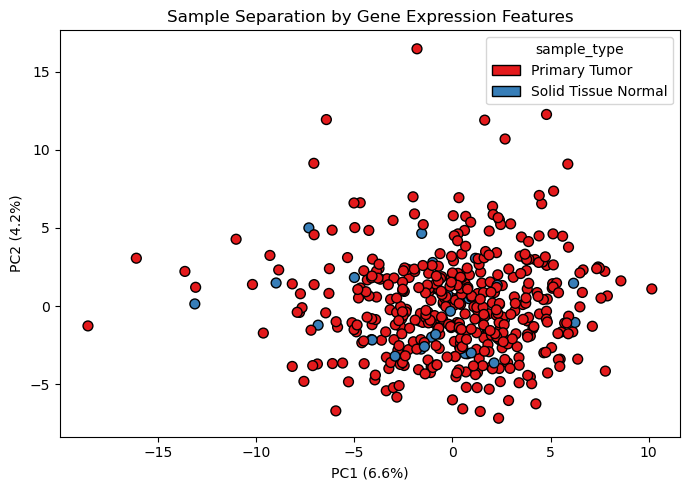

In [30]:
# plot the pca results
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

# map statuses to distinct colors
statuses = list(sample_pca['sample_type'].unique())
cmap = plt.get_cmap('Set1')
color_map = {s: cmap(i % cmap.N) for i, s in enumerate(statuses)}
colors = sample_pca['sample_type'].map(color_map)

# create figure and axes, scatter and attach colorbar to that axes
fig, ax = plt.subplots(figsize=(7,5))
sc = ax.scatter(sample_pca['PC1'], sample_pca['PC2'], s=50, edgecolor='k',c=list(colors))

# simple legend with colored patches
legend_elements = [Patch(facecolor=col, edgecolor='k', label=label) 
                   for label, col in color_map.items()]
ax.legend(handles=legend_elements, title='sample_type')

# labels and colorbar
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title('Sample Separation by Gene Expression Features')
plt.tight_layout()
plt.show()

In [11]:
# It's usually a good idea to us a dimensionality reduction method to look for outliers and distributions of samples
# Here we will do a basic PCA

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# scale features, run PCA on 2-dimensions
X = metData.values
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)
sample_pca = pd.DataFrame(pcs, columns=['PC1', 'PC2'], index=metData.index)

# add the sample_type so we can see if cancerous and non-cancerous samples are split
sample_pca = sample_pca.join(metMeta['sample_type'])
sample_pca.index.name = 'sample_id'
print(sample_pca)

                   PC1       PC2    sample_type
sample_id                                      
TCGA-55-7914 -2.584512 -0.816278  Primary Tumor
TCGA-38-4631 -6.288779  0.805443  Primary Tumor
TCGA-73-4658 -0.740890 -1.427563  Primary Tumor
TCGA-50-5932 -3.951857 -4.724761  Primary Tumor
TCGA-55-7576  4.800875  2.600760  Primary Tumor
...                ...       ...            ...
TCGA-50-8457  3.604576 -0.854583  Primary Tumor
TCGA-91-6840 -5.922355 -1.004132  Primary Tumor
TCGA-86-8280  0.455018 -1.491086  Primary Tumor
TCGA-95-A4VK -2.730536 -0.932395  Primary Tumor
TCGA-55-6969 -4.254740  4.837404  Primary Tumor

[459 rows x 3 columns]


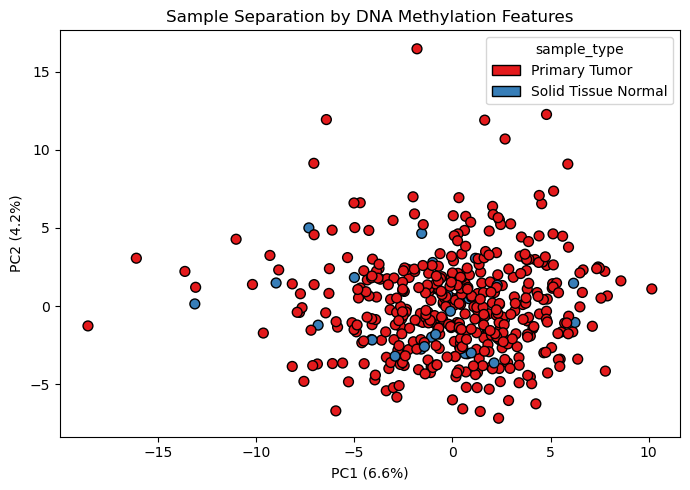

In [12]:
# plot the pca results
from matplotlib.patches import Patch
import matplotlib.pyplot as plt

# map statuses to distinct colors
statuses = list(sample_pca['sample_type'].unique())
cmap = plt.get_cmap('Set1')
color_map = {s: cmap(i % cmap.N) for i, s in enumerate(statuses)}
colors = sample_pca['sample_type'].map(color_map)

# create figure and axes, scatter and attach colorbar to that axes
fig, ax = plt.subplots(figsize=(7,5))
sc = ax.scatter(sample_pca['PC1'], sample_pca['PC2'], s=50, edgecolor='k',c=list(colors))

# simple legend with colored patches
legend_elements = [Patch(facecolor=col, edgecolor='k', label=label) 
                   for label, col in color_map.items()]
ax.legend(handles=legend_elements, title='sample_type')

# labels and colorbar
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title('Sample Separation by DNA Methylation Features')
plt.tight_layout()
plt.show()

In [13]:
# We will re-use some of the graph functions we worked with in our networks notebooks
import graph_functions as gf

# transform the gene expresison matrix so we can create a patient correlation matrix
pat_expData = expData.T

# create a dict() to hold our correlation matrices
correlation_matrices={}

# Pearson correlation - O(n^2) complexity, fast for large datasets
exp_corr = pat_expData.corr(method='pearson') # continuous variable

# add the matrix to our dict
correlation_matrices['expression'] = exp_corr

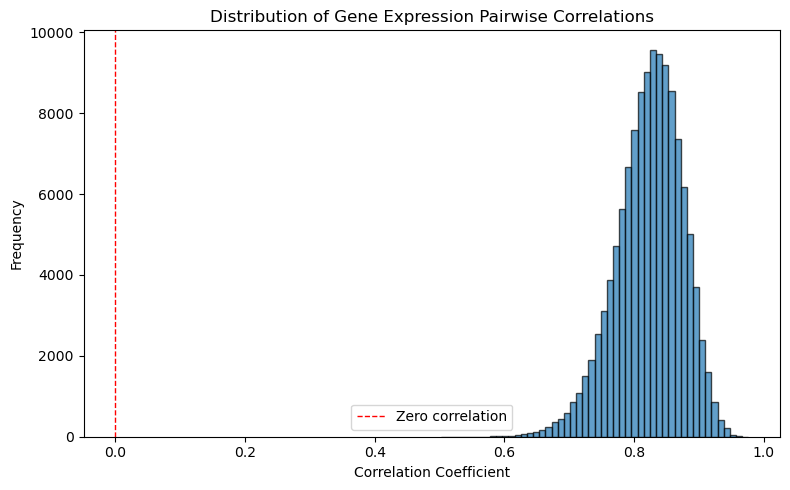

Mean correlation: 0.8227
Median correlation: 0.8270
Std deviation: 0.0508
Min correlation: 0.5018
Max correlation: 0.9760


In [14]:
# plot histogram of correlation values
import matplotlib.pyplot as plt
import numpy as np

# Extract upper triangle of correlation matrix (to avoid duplicates and diagonal)
upper_triangle_mask = np.triu(np.ones_like(exp_corr, dtype=bool), k=1)
correlation_values = exp_corr.where(upper_triangle_mask).values.flatten()
correlation_values = correlation_values[~np.isnan(correlation_values)]

# Plot histogram
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(correlation_values, bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Correlation Coefficient')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Gene Expression Pairwise Correlations')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Zero correlation')
ax.legend()
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Mean correlation: {correlation_values.mean():.4f}")
print(f"Median correlation: {np.median(correlation_values):.4f}")
print(f"Std deviation: {correlation_values.std():.4f}")
print(f"Min correlation: {correlation_values.min():.4f}")
print(f"Max correlation: {correlation_values.max():.4f}")

In [31]:
# repeat for our methylation data
pat_metData = metData.T

# Pearson correlation - O(n^2) complexity, fast for large datasets
met_corr = pat_metData.corr(method='pearson')

# add this to our correlation matrix dict
correlation_matrices['methylation'] = met_corr

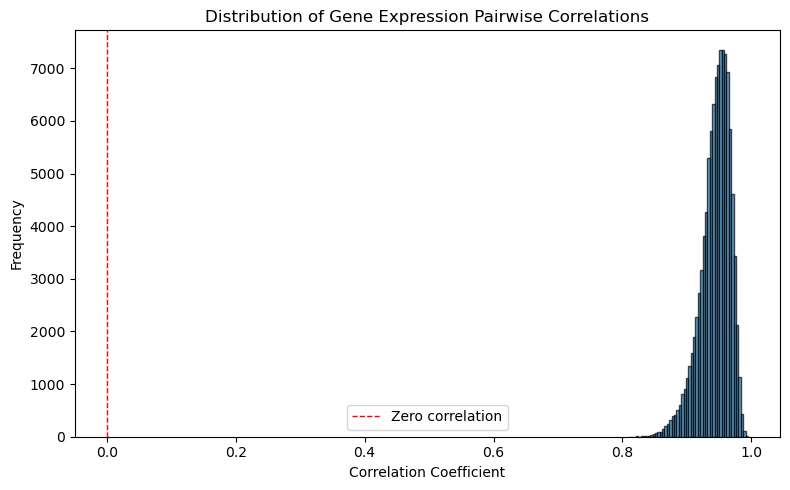

Mean correlation: 0.9437
Median correlation: 0.9473
Std deviation: 0.0232
Min correlation: 0.8097
Max correlation: 0.9948


In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Extract upper triangle of correlation matrix (to avoid duplicates and diagonal)
upper_triangle_mask = np.triu(np.ones_like(met_corr, dtype=bool), k=1)
correlation_values = met_corr.where(upper_triangle_mask).values.flatten()
correlation_values = correlation_values[~np.isnan(correlation_values)]

# Plot histogram
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(correlation_values, bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Correlation Coefficient')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Gene Expression Pairwise Correlations')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Zero correlation')
ax.legend()
plt.tight_layout()
plt.show()

# Print summary statistics
print(f"Mean correlation: {correlation_values.mean():.4f}")
print(f"Median correlation: {np.median(correlation_values):.4f}")
print(f"Std deviation: {correlation_values.std():.4f}")
print(f"Min correlation: {correlation_values.min():.4f}")
print(f"Max correlation: {correlation_values.max():.4f}")

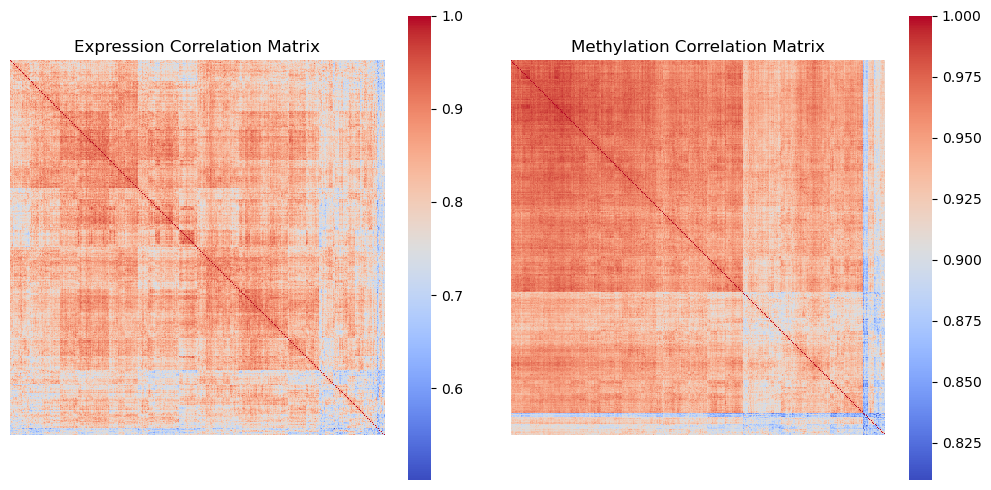

In [33]:
# plot the matrices side-by-side
gf.plot_correlation_matrices(correlation_matrices)

There is structure in this, there are blocks, this can be indicative of cluserts. The methylation seems to give one big block, and the other might have small ones

In [34]:
# Create a graph from the Pearson correlation matrices with select thresholds (you could play with these, I've picked just above median)

# the PSN for expression data
patExpGraph = gf.create_graph_from_correlation(correlation_matrices['expression'], threshold=0.85)

# the PSN for methylation data
patMetGraph = gf.create_graph_from_correlation(correlation_matrices['methylation'], threshold=0.95)

In [35]:
#add in missing patients from either graph (now we can weave in patients missing data from either modality)

## Key idea, we can add unconnected node of removed patients and if the other modality had important information, the signal added new networks may reconnect the 
# patient. This will then be fused.

# get the expression graph patient ids
expPatients = patExpGraph.nodes()
print(f'There are',len(expPatients),'patients in the expression graph')

# get the methylation graph patient ids
metPatients = patMetGraph.nodes()
print(f'There are',len(metPatients),'patients in the methylation graph')

#add nodes to methylation graph for patients that are in expression data but not in methylation
patMetGraph.add_nodes_from(list(set(expPatients)-set(metPatients)))

#add nodes to expression graph for patients that are in methylation data but not in expression
patExpGraph.add_nodes_from(list(set(metPatients)-set(expPatients)))

# get the expression graph patient ids
expPatients = patExpGraph.nodes()
print(f'There are now',len(expPatients),'patients in the expression graph')

# get the methylation graph patient ids
metPatients = patMetGraph.nodes()
print(f'There are now',len(metPatients),'patients in the methylation graph')

graphs = [patExpGraph,patMetGraph]

There are 498 patients in the expression graph
There are 459 patients in the methylation graph
There are now 515 patients in the expression graph
There are now 515 patients in the methylation graph


In [36]:
# SNF fusion 

## Be careful:
# WE want that the nodes are the same in both graphs as a technical note
# We can pick one of the graphs, and we can change the order of all other graphs to match the adjacency matrices of all networks for correct fusion

# we need to make sure the nodes are in the same order in both graphs
nodes = sorted(patExpGraph.nodes())

# extract the adjacency matrices to perform SNF
A1 = nx.to_numpy_array(patExpGraph, nodelist=nodes, weight="weight")
A2 = nx.to_numpy_array(patMetGraph, nodelist=nodes, weight="weight")

# add the matrices to a list for the snf function
allgraphs = [A1,A2]

# perform SNF
affinity_networks = snf.make_affinity(allgraphs, metric='euclidean', K=20, mu=0.5)
# fuse the networks
fused_network = snf.snf(affinity_networks, K=20, t=20)

# remove self-loops
np.fill_diagonal(fused_network, 0)

In [37]:
# This fused network will be completely connected (like a correlation matrix) # Lot of edge weights, weak down, strong up!
# We will use kNN to sparsify it

# retain only up to the 5 strongest edges per node - THis is just saying, a node may have maxium of K (=5) strongest connected nodes
k = 5

# create an empty matrix to hold the edges we retain
A_knn = np.zeros_like(fused_network)

### One more caveat, one node may have degree 3, and degree 50, there may be issues in creating a assymetric adjacency matrix, the -inf line below does this to 
# pad out degress less than k


# perform the sparsification
for i in range(fused_network.shape[0]):
    row = fused_network[i].copy()
    row[i] = -np.inf
    idx = np.argsort(row)[-k:]
    A_knn[i, idx] = fused_network[i, idx]

# make sure the resulting matrix is symmetric
A_knn = np.maximum(A_knn, A_knn.T)

# create the graph object
G = nx.from_numpy_array(A_knn)

#add the patient ids back on
node_names = sorted(patExpGraph.nodes())
mapping = {i: node_name for i, node_name in enumerate(node_names)}
G = nx.relabel_nodes(G, mapping)


Average clustering coefficient for Fused Graph: 0.2542


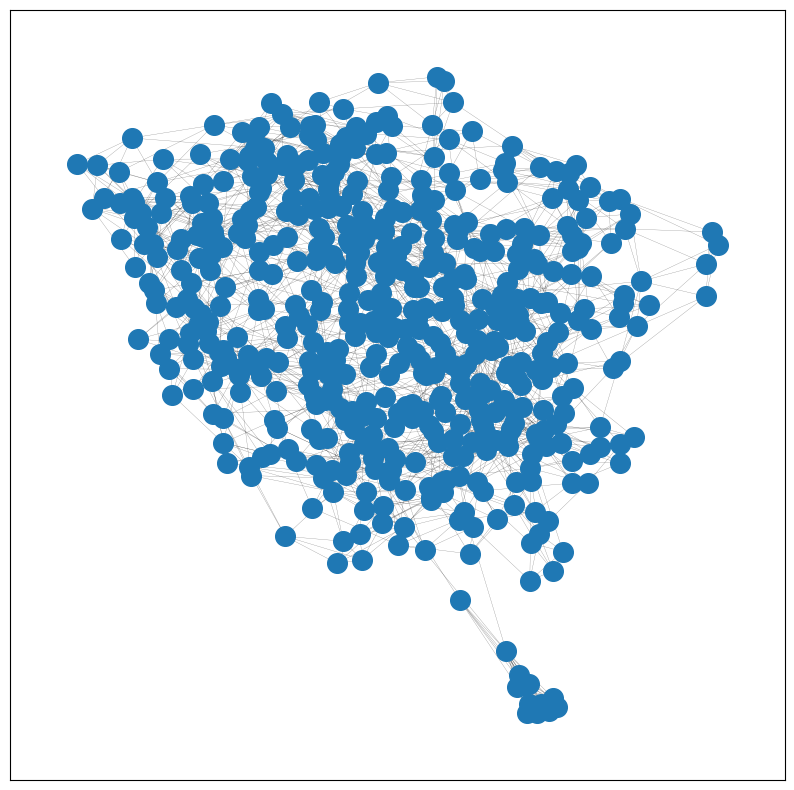

In [38]:
# find the clustering coefficient of the fused graph
clustering_coeffs = nx.clustering(G)
avg_clustering_coeff = sum(clustering_coeffs.values()) / len(clustering_coeffs)
print(f"Average clustering coefficient for Fused Graph: {avg_clustering_coeff:.4f}")

plt.figure(figsize=(10, 10))

pos = nx.spring_layout(G, k=0.1, seed=50)
nx.draw_networkx_nodes(G, pos, node_size=200)
nx.draw_networkx_edges(G, pos, width=0.2, alpha=0.5)
plt.show()

### 
## All patients are retained in this network with edges of different strengths and have maintained information within both modalities

In [39]:
# Combine the MetaData (remembering that some patients were only present in one of the original data modalities)
import pandas as pd

## Fusing the metadata to ensure the attributes are not lost for the fused network

# function to combine these data frames and collapse into unique columns
# THis creates suffixes, it ads _1, _2 and if there is NaN, just collapse and all that
def merge_and_collapse(df1, df2, on):
    # Step 1: outer merge with temporary suffixes
    df_merged = pd.merge(df1, df2, on=on, how='outer', suffixes=('_1', '_2'))

    # Step 2: detect overlapping columns and combine
    cols_1 = [c for c in df_merged.columns if c.endswith('_1')]
    for col_1 in cols_1:
        base_col = col_1[:-2]
        col_2 = f'{base_col}_2'
        if col_2 in df_merged.columns:
            df_merged[base_col] = df_merged[col_1].combine_first(df_merged[col_2])
            df_merged = df_merged.drop(columns=[col_1, col_2])
        else:
            # if no _2 version, just rename _1 to base
            df_merged = df_merged.rename(columns={col_1: base_col})

    return df_merged

combinedMeta = merge_and_collapse(metMeta,expMeta,'patient')


In [40]:
combinedMeta.head()

,patient,sizeFactor,replaceable,race,gender,sample_type,cigarettes_per_day,Smoked
0,TCGA-05-4244,1.4527,True,not reported,male,Primary Tumor,2.0822,Smoker
1,TCGA-05-4249,1.4804,True,not reported,male,Primary Tumor,2.8493,Smoker
2,TCGA-05-4250,1.3624,True,not reported,female,Primary Tumor,2.5753,Smoker
3,TCGA-05-4382,2.1295,True,not reported,male,Primary Tumor,3.3973,Smoker
4,TCGA-05-4384,0.8082,True,not reported,male,Primary Tumor,1.09589,Smoker


In [41]:
# A nice function that will take the fused network object and the metadata frame and allow us to plot with names and colour by attribute
def plot_snf_network(G, node_names, df, attr_col, cmap='tab10', node_size=100, with_labels=True):
    """
    Build a network from SNF adjacency matrix, relabel nodes with patient IDs,
    and plot colored by a categorical DataFrame attribute.

    Parameters:
    - A_knn: SNF adjacency matrix (numpy array)
    - node_names: list of node IDs in the same order as A_knn
    - df: DataFrame containing node attributes
    - attr_col: column in df to color nodes by
    - cmap: matplotlib colormap
    - node_size: size of nodes in plot
    - with_labels: whether to show labels
    """
    # Step 3: Prepare node attribute mapping
    df_sub = df.set_index('patient')
    node_attrs = df_sub[attr_col].to_dict()

    # Step 4: Generate colors for each category
    categories = list(sorted(set(node_attrs.values())))
    colormap = plt.get_cmap(cmap)
    n = len(categories)
    category_colors = {cat: matplotlib.colors.to_hex(colormap(i / max(1, n-1)))
                    for i, cat in enumerate(categories)}

    # Step 5: Assign node colors
    node_color_list = [category_colors.get(node_attrs.get(node, None), '#D3D3D3') 
                    for node in G.nodes()]

    # Step 6: Layout and draw
    pos = nx.spring_layout(G, seed=42, k=10.0)
    plt.figure(figsize=(10, 10))
    nx.draw(G, pos, node_color=node_color_list, with_labels=with_labels, node_size=node_size, edge_color='lightgray', font_size=8)

    # Step 7: Add legend
    legend_elements = [Patch(facecolor=color, label=cat) for cat, color in category_colors.items()]
    plt.legend(handles=legend_elements)
    plt.show()

    return G

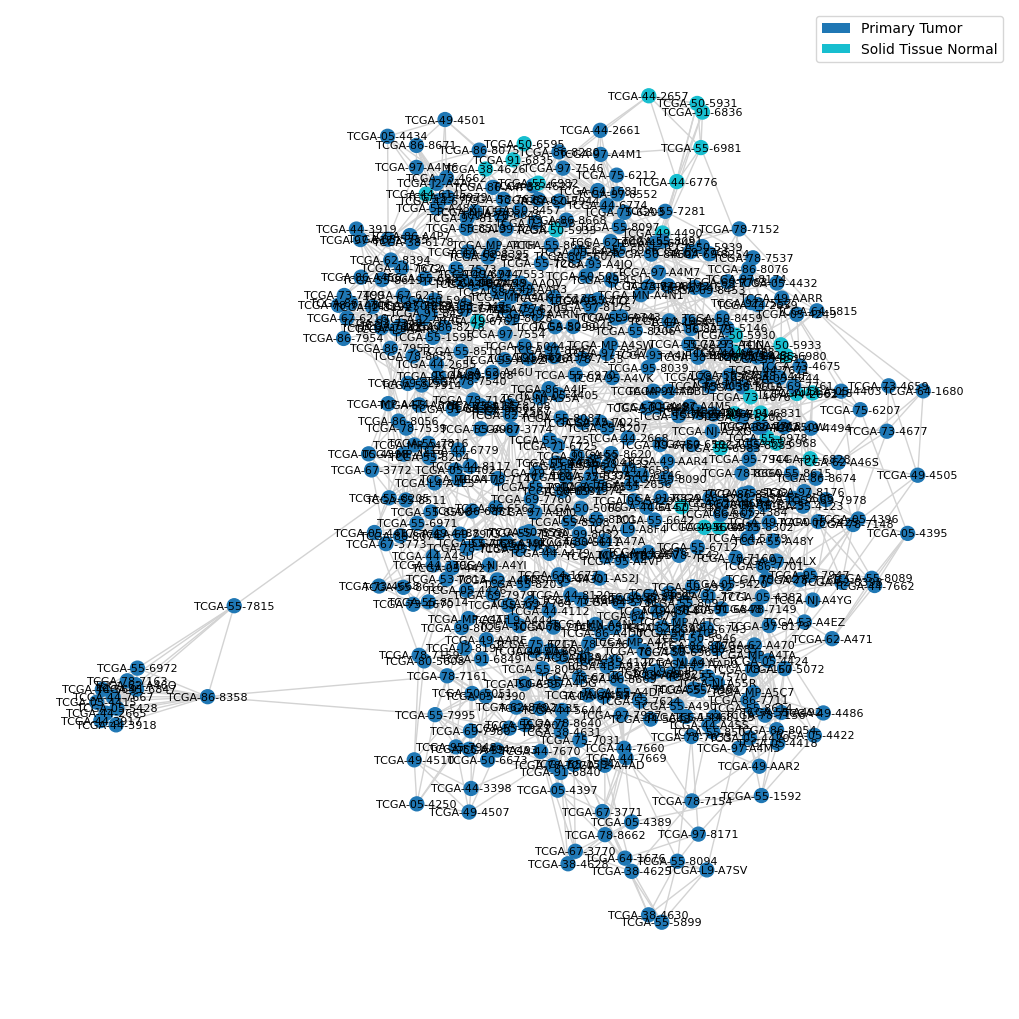

In [42]:
plot_snf_network(G,node_names,combinedMeta,'sample_type');

In [44]:
# Cluster the gene correlation network using the greedy modularity communities algorithm

# Louvain with resolution
from community import community_louvain

partition = community_louvain.best_partition(G, resolution=0.9)
# Increase resolution (>1) -> more communities (finer)
# Decrease resolution (<1) -> fewer communities (coarser)

from collections import defaultdict

clusters = defaultdict(set)
for node, cluster_id in partition.items():
    clusters[cluster_id].add(node)
communities = list(clusters.values())

print(f'There are',len(communities),'communities')

There are 15 communities


Community 1 has 49 nodes.


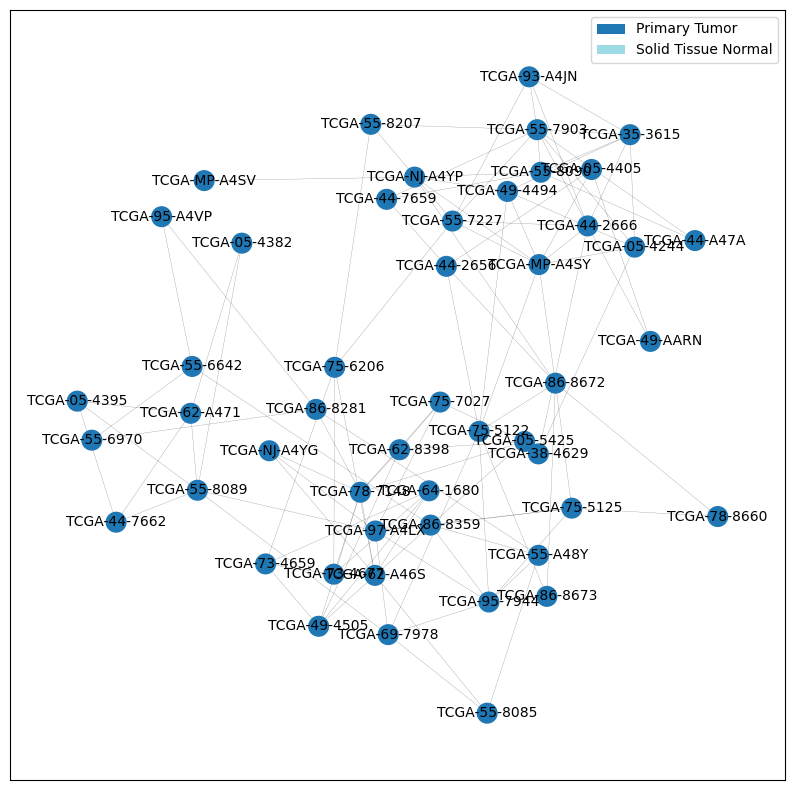

Community 2 has 38 nodes.


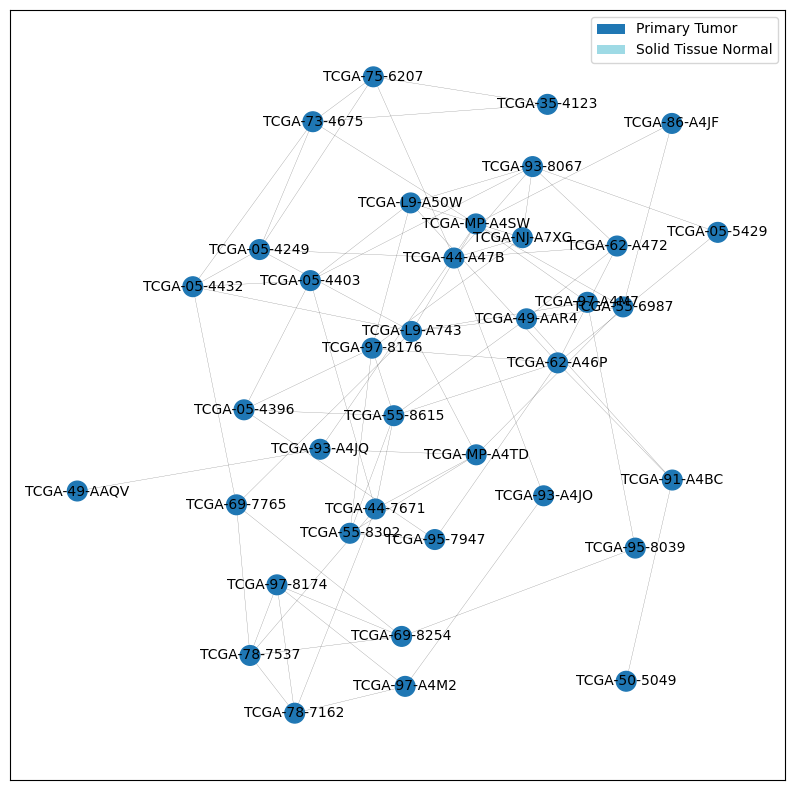

Community 3 has 38 nodes.


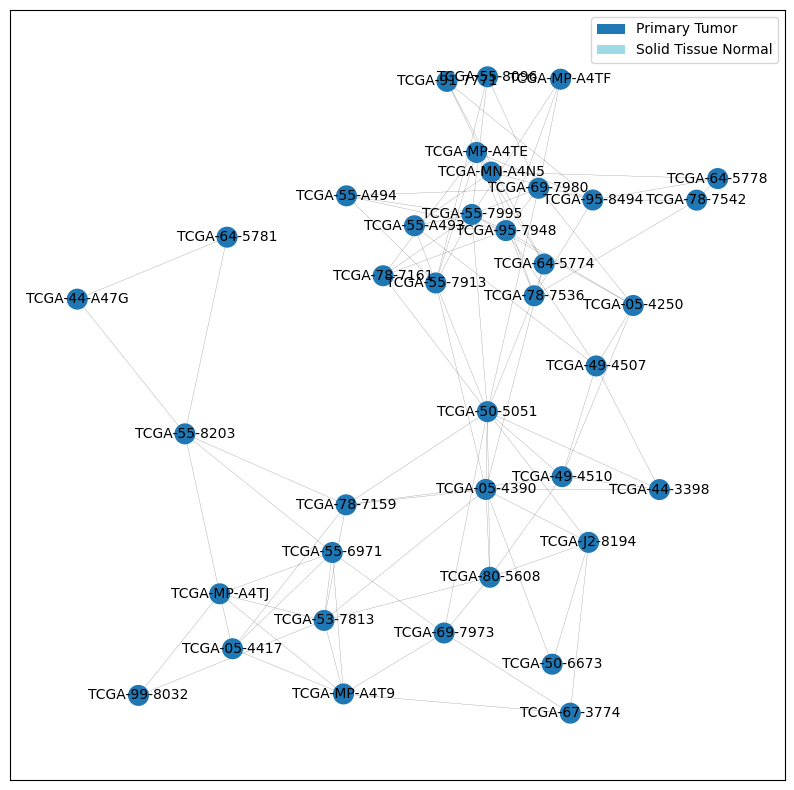

Community 4 has 37 nodes.


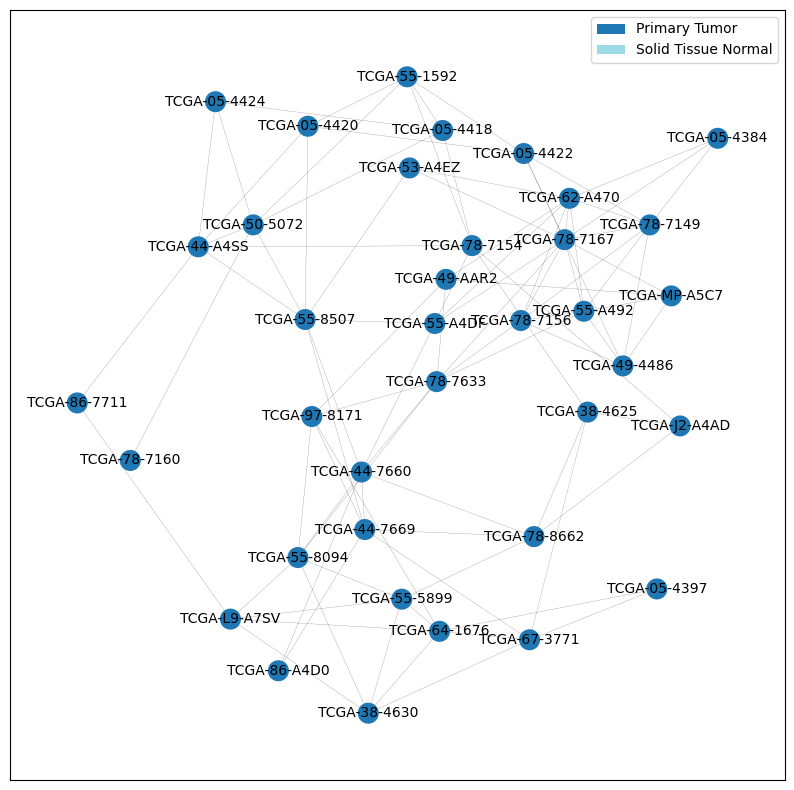

Community 5 has 53 nodes.


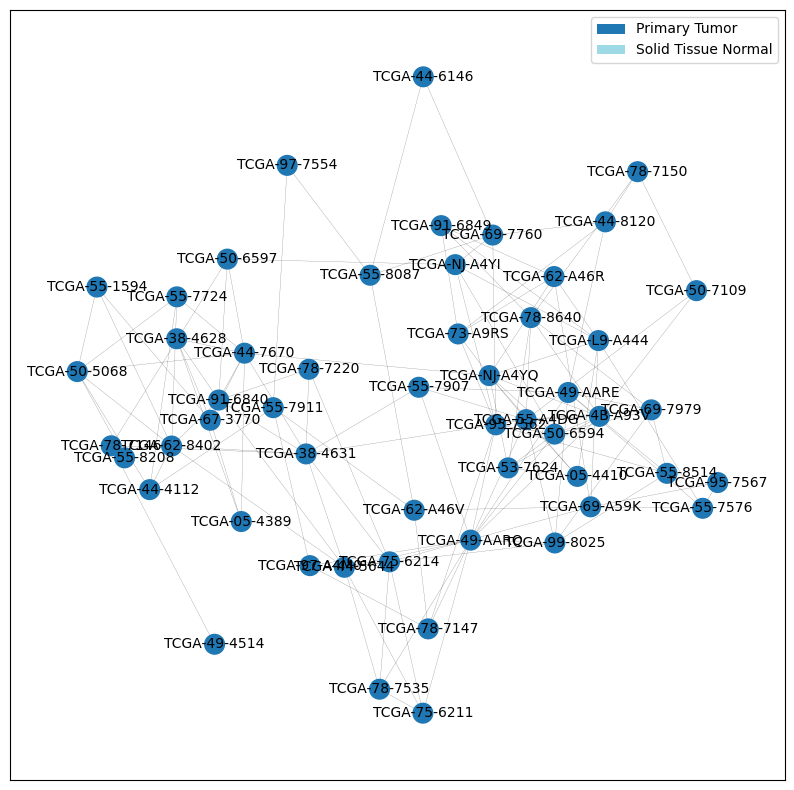

Community 6 has 59 nodes.


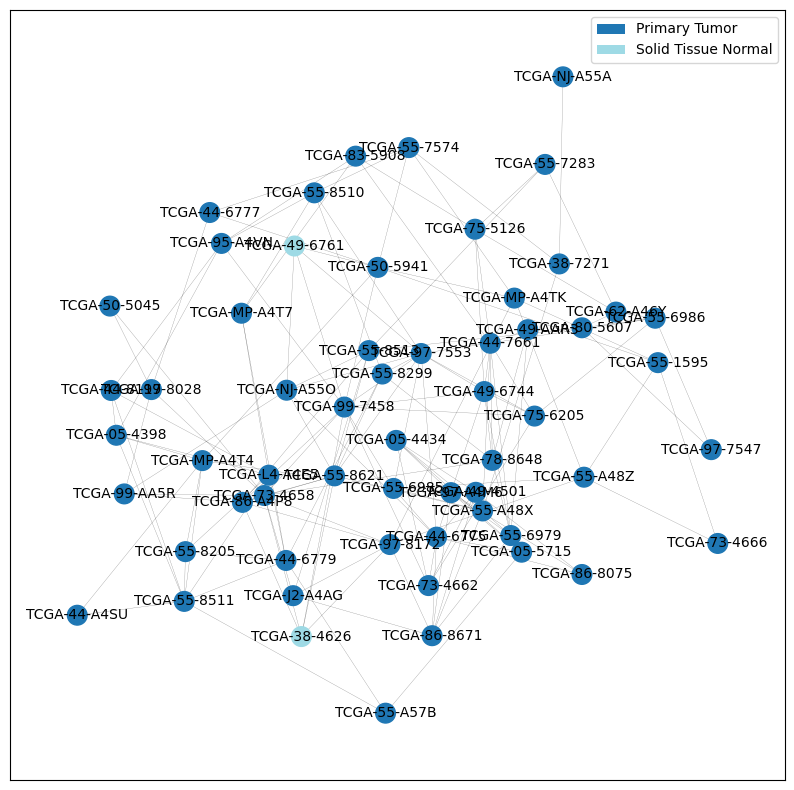

Community 7 has 24 nodes.


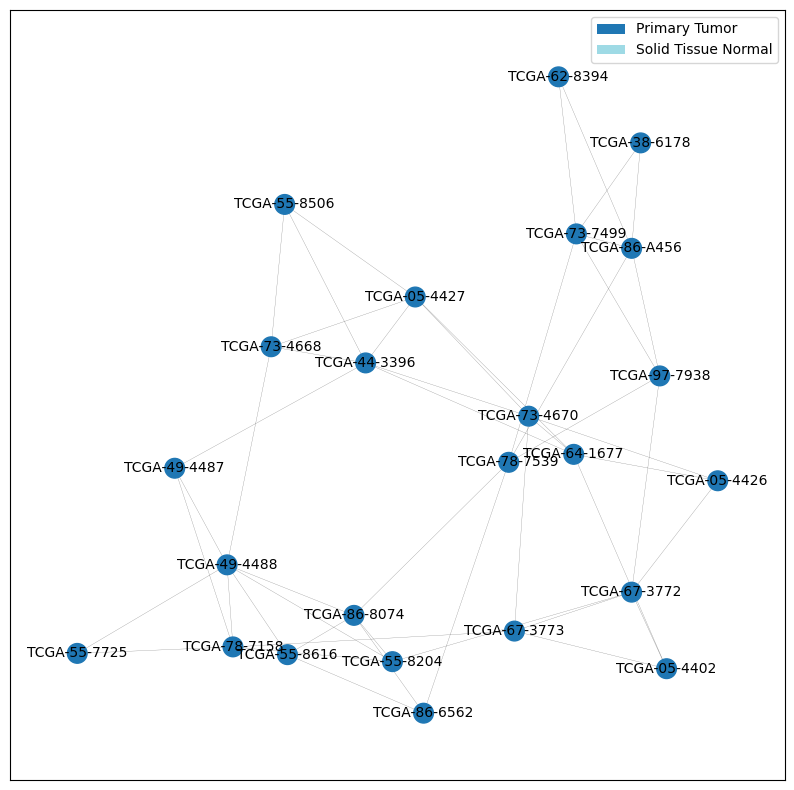

Community 8 has 13 nodes.


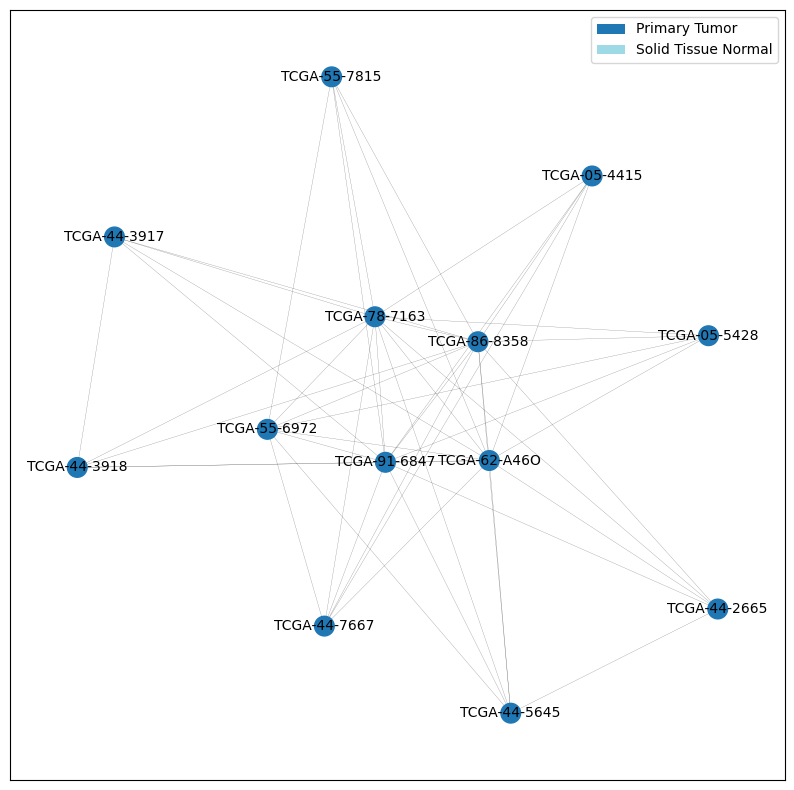

Community 9 has 39 nodes.


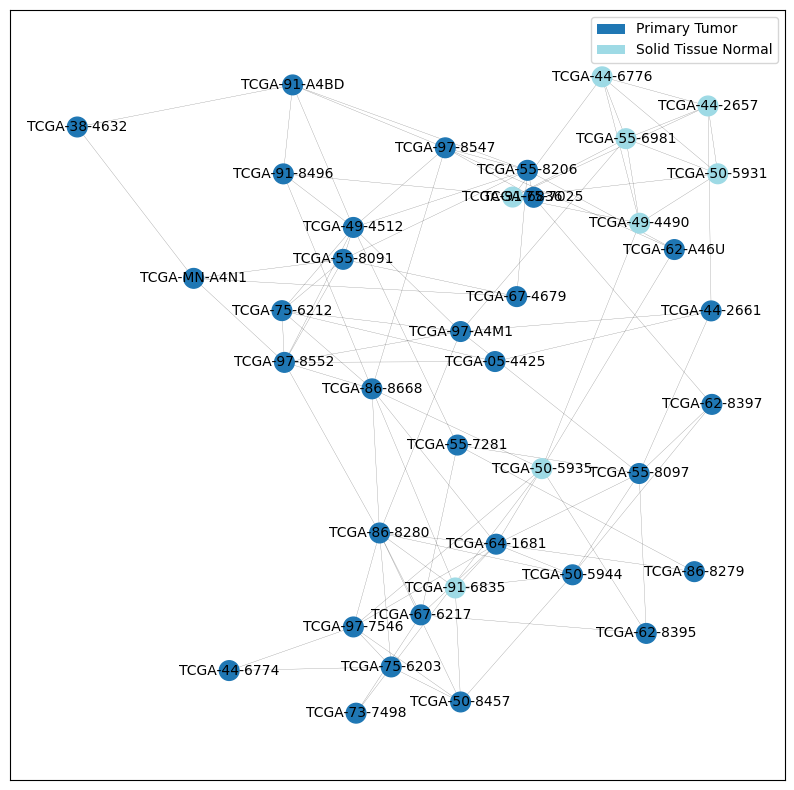

Community 10 has 32 nodes.


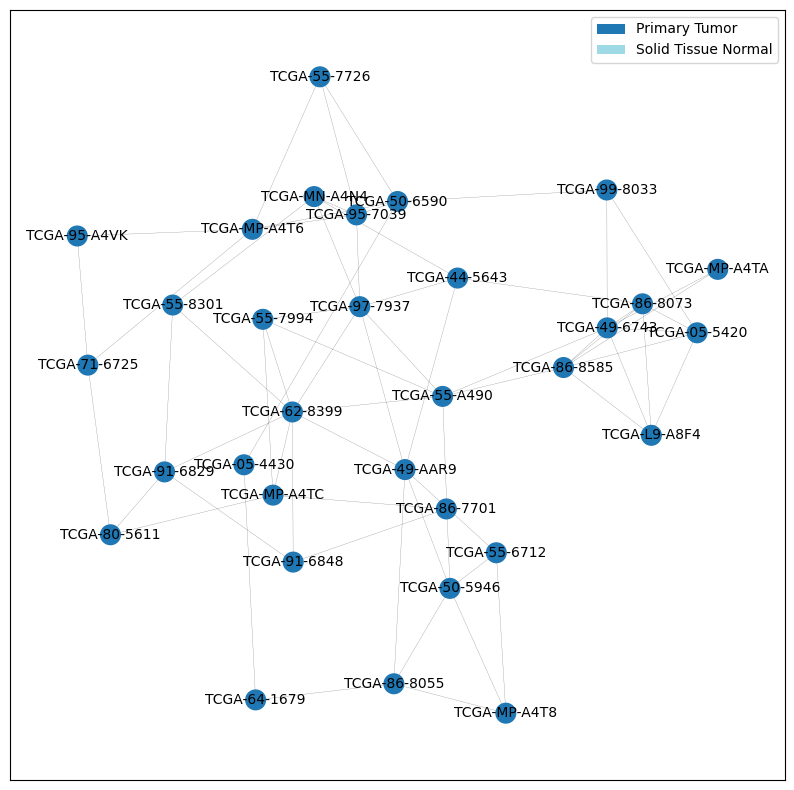

Community 11 has 16 nodes.


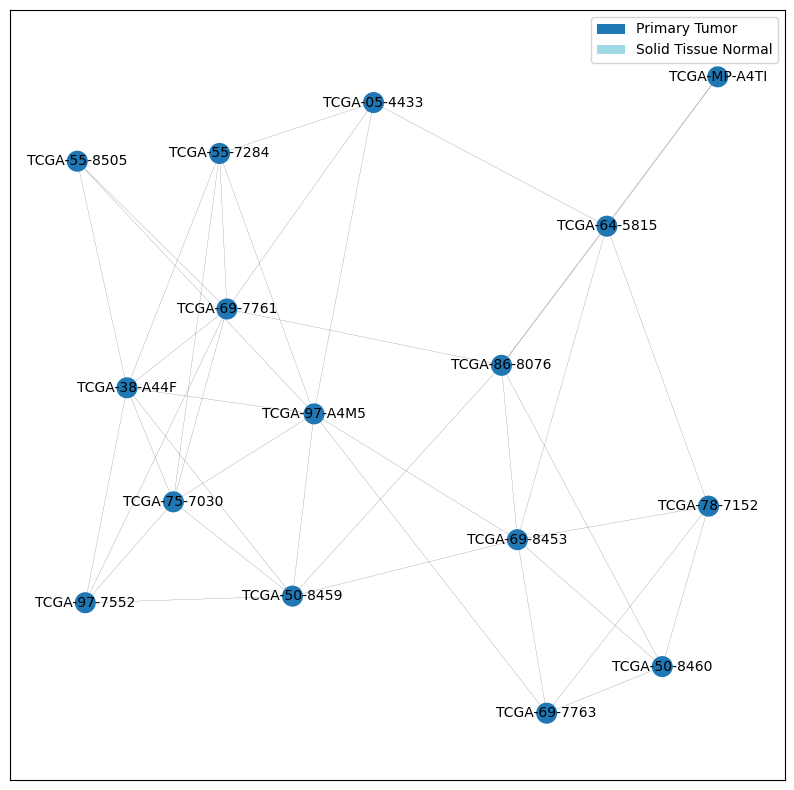

Community 12 has 38 nodes.


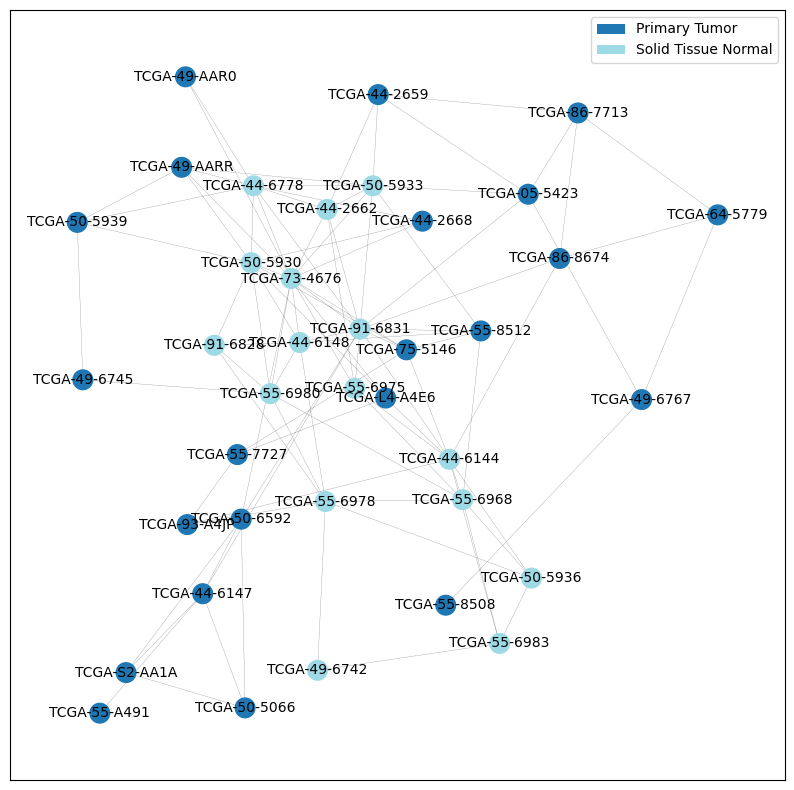

Community 13 has 23 nodes.


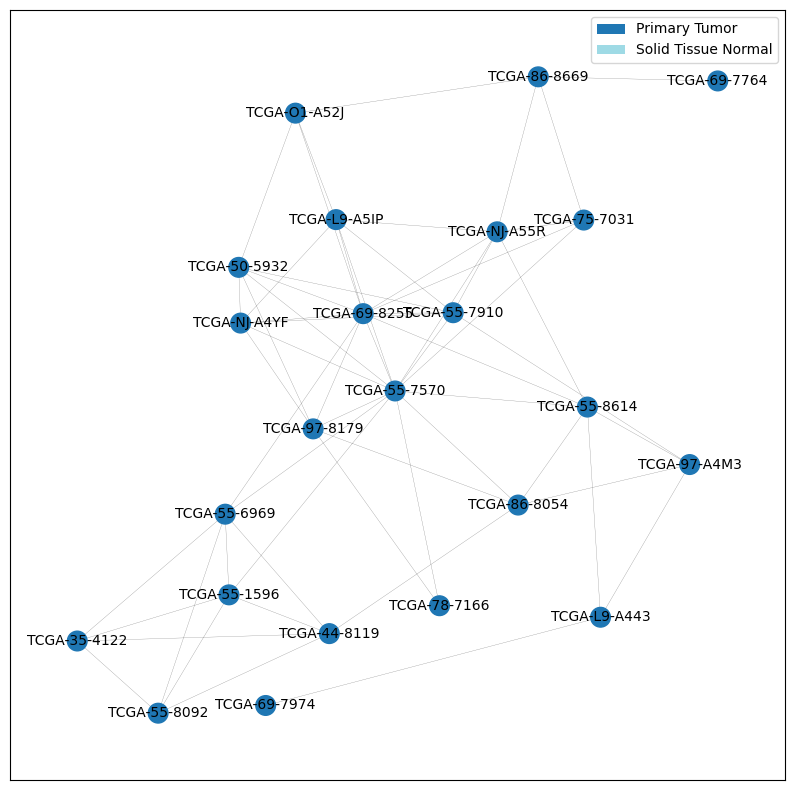

Community 14 has 8 nodes.


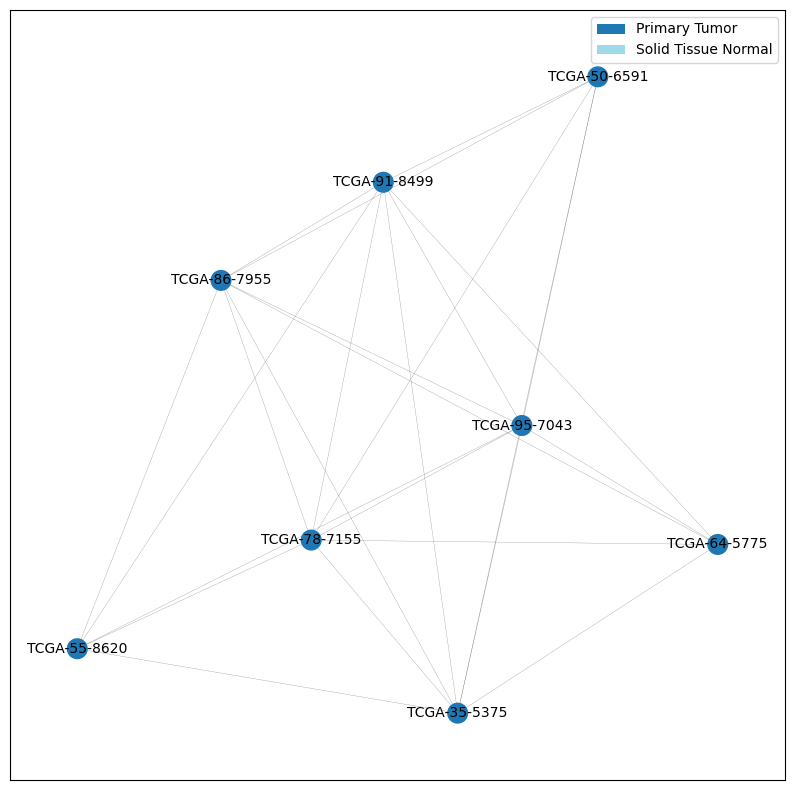

Community 15 has 48 nodes.


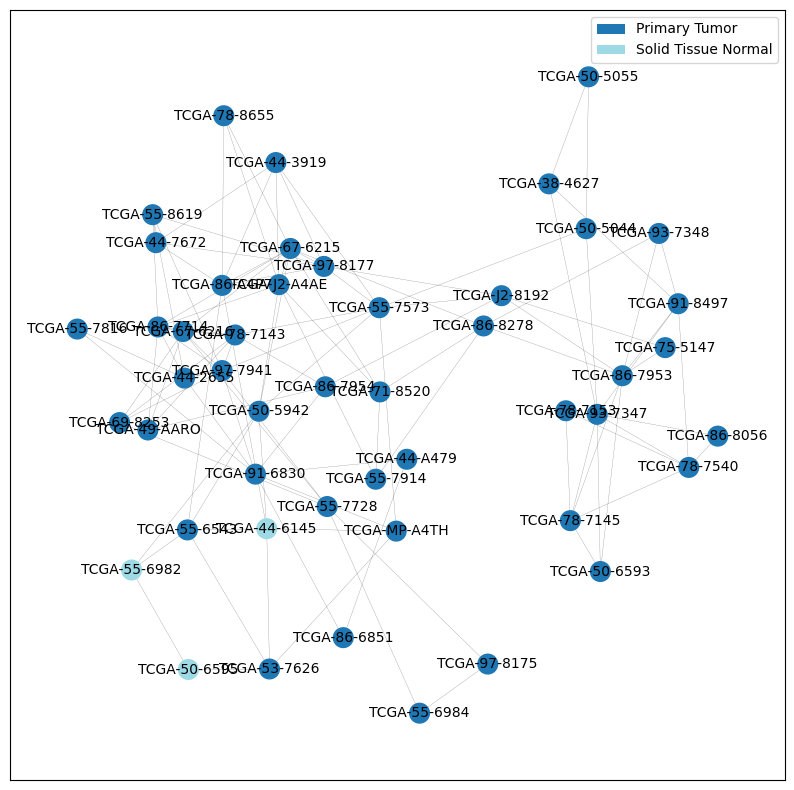

In [45]:
# Now we're going to plot the patient clusters with nodes colour coded by patient attributes

# Create a mapping from patient -> attribute
df_sub = combinedMeta.set_index('patient')
node_attrs = df_sub['sample_type'].to_dict()  # replace 'sample_type' with your attribute column
# node_attrs = df_sub['gender'].to_dict()  # replace 'sample_type' with your attribute column
# node_attrs = df_sub['race'].to_dict()  # replace 'sample_type' with your attribute column

# Get unique categories and assign colors
categories = sorted(set(node_attrs.values()))
colormap = plt.get_cmap('tab20')
category_colors = {cat: matplotlib.colors.to_hex(colormap(i / max(1, len(categories)-1)))
                   for i, cat in enumerate(categories)}

# Create subgraphs for each community
subgraphs = [G.subgraph(c) for c in communities]

for i, subgraph in enumerate(subgraphs):
    print(f'Community {i+1} has {subgraph.number_of_nodes()} nodes.')
    
    # Create list of node colors based on attribute
    node_color_list = [category_colors.get(node_attrs.get(node, None), '#D3D3D3')  # grey if missing
                       for node in subgraph.nodes()]
    
    plt.figure(figsize=(10, 10))
    pos = nx.spring_layout(subgraph, k=0.1, seed=50)
    nx.draw_networkx_nodes(subgraph, pos, node_size=200, node_color=node_color_list)
    nx.draw_networkx_edges(subgraph, pos, width=0.2, alpha=0.5)
    nx.draw_networkx_labels(subgraph, pos, font_size=10, font_color='black')
    
    # Optional: add legend for attribute colors
    legend_elements = [Patch(facecolor=color, label=cat) for cat, color in category_colors.items()]
    plt.legend(handles=legend_elements)
    
    plt.show()


### Notes:
This was a relatively rough and ready approach especially the feature selection
We were able to keep 50 patients we would have lost otherwise stratight away
The subcommunities that are mixed may have issues in idenetifying early onset, or difficult to diagnosed cancer for heterogeneity
You can stratify by different subgroups e.g. gender, ethnicities, smoker as seen above
There may be genetic ancestories that give founder effects that have spread through the population that give higher levels of predisposition to certain diseases
This is a confounding sample